In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the renamed dataset (german_credit.csv already has correct names)
df = pd.read_csv('../data/raw/german_credit.csv')


print("Feature names:")
print(list(df.columns))
print(f"\nShape: {df.shape}")
print(f"\nClass distribution:")
print(df['credit_risk'].value_counts())
print(f"\nGood credit (0): {(df['credit_risk']==0).sum()} — {(df['credit_risk']==0).mean():.0%}")
print(f"Bad  credit (1): {(df['credit_risk']==1).sum()} — {(df['credit_risk']==1).mean():.0%}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Feature names:
['checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_years', 'installment_rate', 'personal_status', 'other_debtors', 'residence_years', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign_worker', 'credit_risk']

Shape: (1000, 21)

Class distribution:
credit_risk
0    700
1    300
Name: count, dtype: int64

Good credit (0): 700 — 70%
Bad  credit (1): 300 — 30%

Missing values: 0


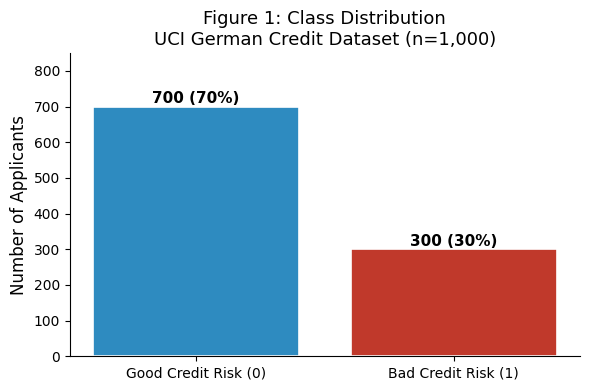

Saved: shap_plots/class_distribution.png


In [7]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['credit_risk'].value_counts().sort_index()
bars = ax.bar(
    ['Good Credit Risk (0)', 'Bad Credit Risk (1)'],
    counts.values,
    color=['#2E8BC0', '#C0392B'],
    edgecolor='white', linewidth=1.2
)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'{count} ({count/len(df):.0%})',
            ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.set_title('Figure 1: Class Distribution\nUCI German Credit Dataset (n=1,000)', fontsize=13)
ax.set_ylim(0, 850)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../shap_plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_plots/class_distribution.png")

In [8]:
# Separate categorical and numerical features
target = 'credit_risk'
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns
            if c != target]

print(f"NUMERICAL features ({len(num_cols)}):")
for c in num_cols:
    print(f"  {c:<25} min={df[c].min()}, max={df[c].max()}, mean={df[c].mean():.1f}")

print(f"\nCATEGORICAL features ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c:<25} {df[c].nunique()} unique values")

NUMERICAL features (7):
  duration_months           min=4, max=72, mean=20.9
  credit_amount             min=250, max=18424, mean=3271.3
  installment_rate          min=1, max=4, mean=3.0
  residence_years           min=1, max=4, mean=2.8
  age                       min=19, max=75, mean=35.5
  existing_credits          min=1, max=4, mean=1.4
  num_dependents            min=1, max=2, mean=1.2

CATEGORICAL features (13):
  checking_account          4 unique values
  credit_history            5 unique values
  purpose                   10 unique values
  savings_account           5 unique values
  employment_years          5 unique values
  personal_status           4 unique values
  other_debtors             3 unique values
  property                  4 unique values
  other_installments        3 unique values
  housing                   3 unique values
  job                       4 unique values
  telephone                 2 unique values
  foreign_worker            2 unique values


C:\Users\capsy\AppData\Local\Temp\ipykernel_37104\2821171543.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


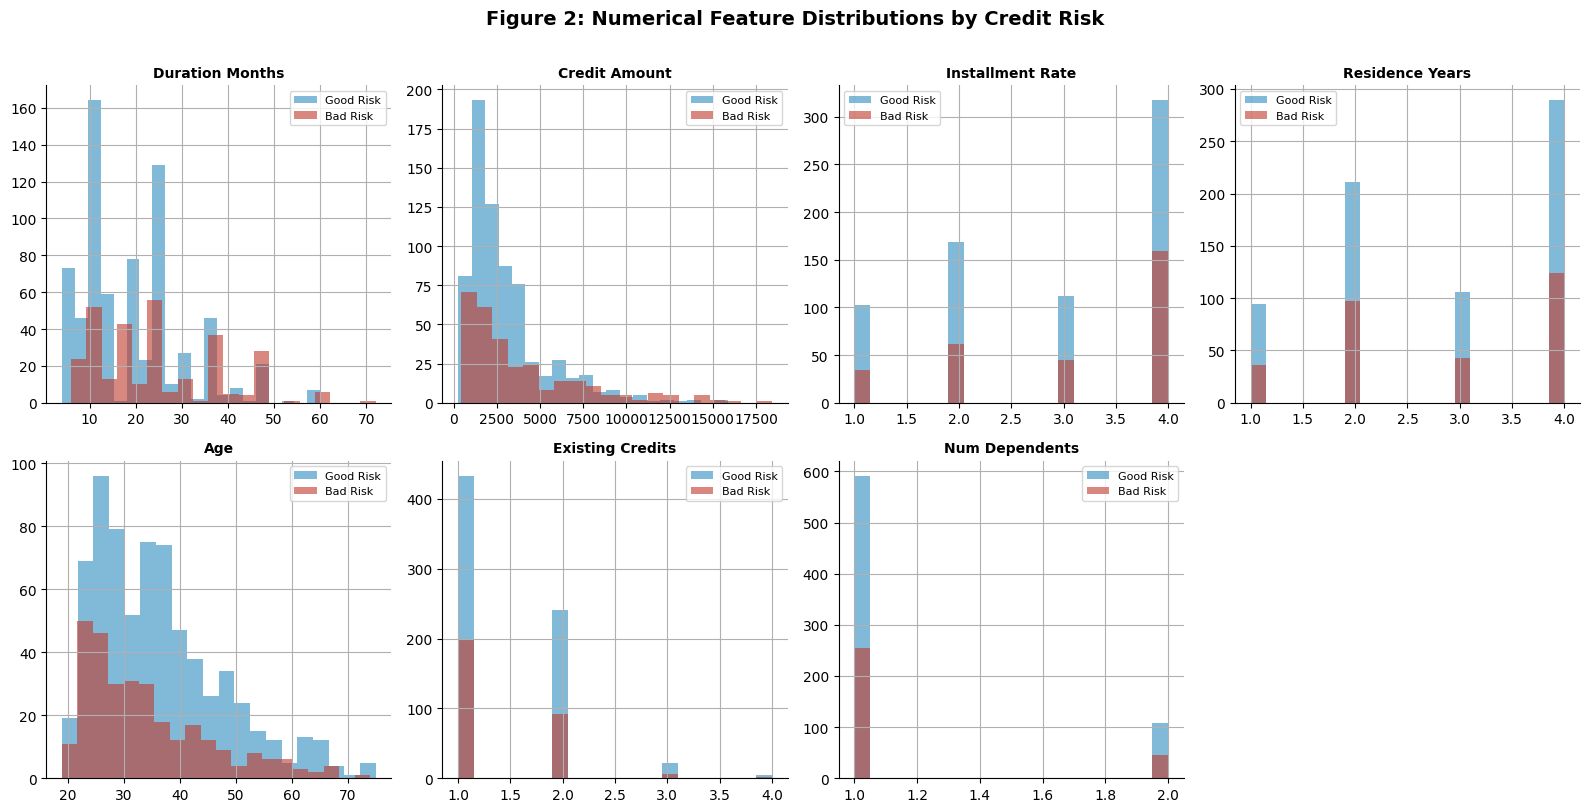

Saved: shap_plots/numerical_distributions.png


In [9]:
# Numerical feature distributions split by credit risk
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df[df['credit_risk']==0][col].hist(
        ax=ax, alpha=0.6, label='Good Risk', color='#2E8BC0', bins=20)
    df[df['credit_risk']==1][col].hist(
        ax=ax, alpha=0.6, label='Bad Risk', color='#C0392B', bins=20)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots if any
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figure 2: Numerical Feature Distributions by Credit Risk',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../shap_plots/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_plots/numerical_distributions.png")

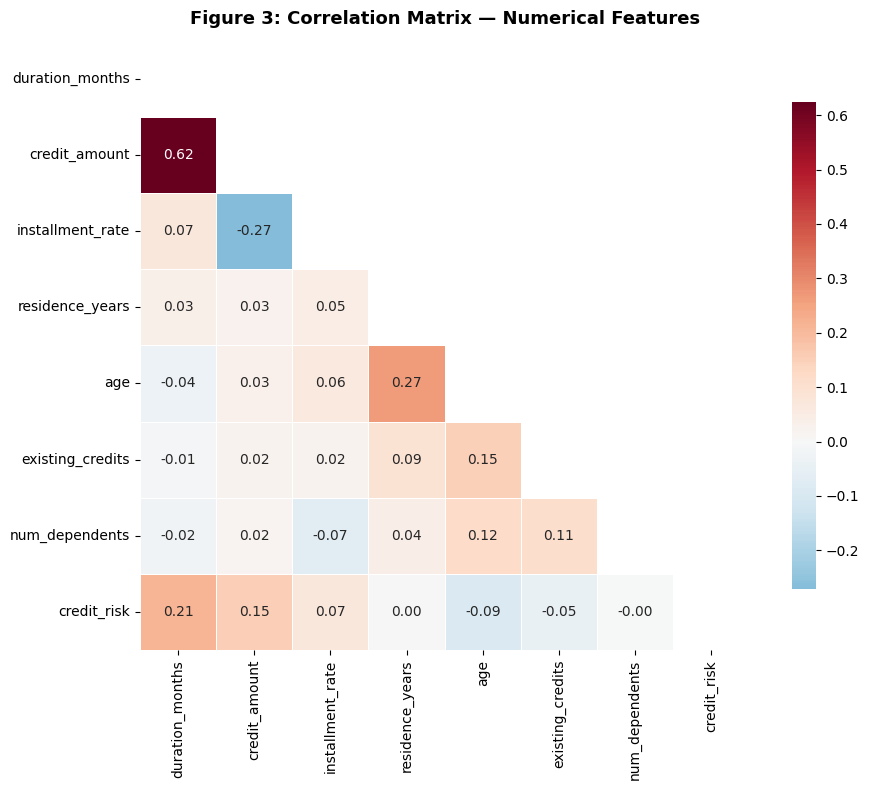

Saved: shap_plots/correlation_heatmap.png


In [10]:
# Correlation heatmap — numerical features only
num_df = df[num_cols + ['credit_risk']].copy()

fig, ax = plt.subplots(figsize=(10, 8))
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

ax.set_title('Figure 3: Correlation Matrix — Numerical Features',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('../shap_plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_plots/correlation_heatmap.png")

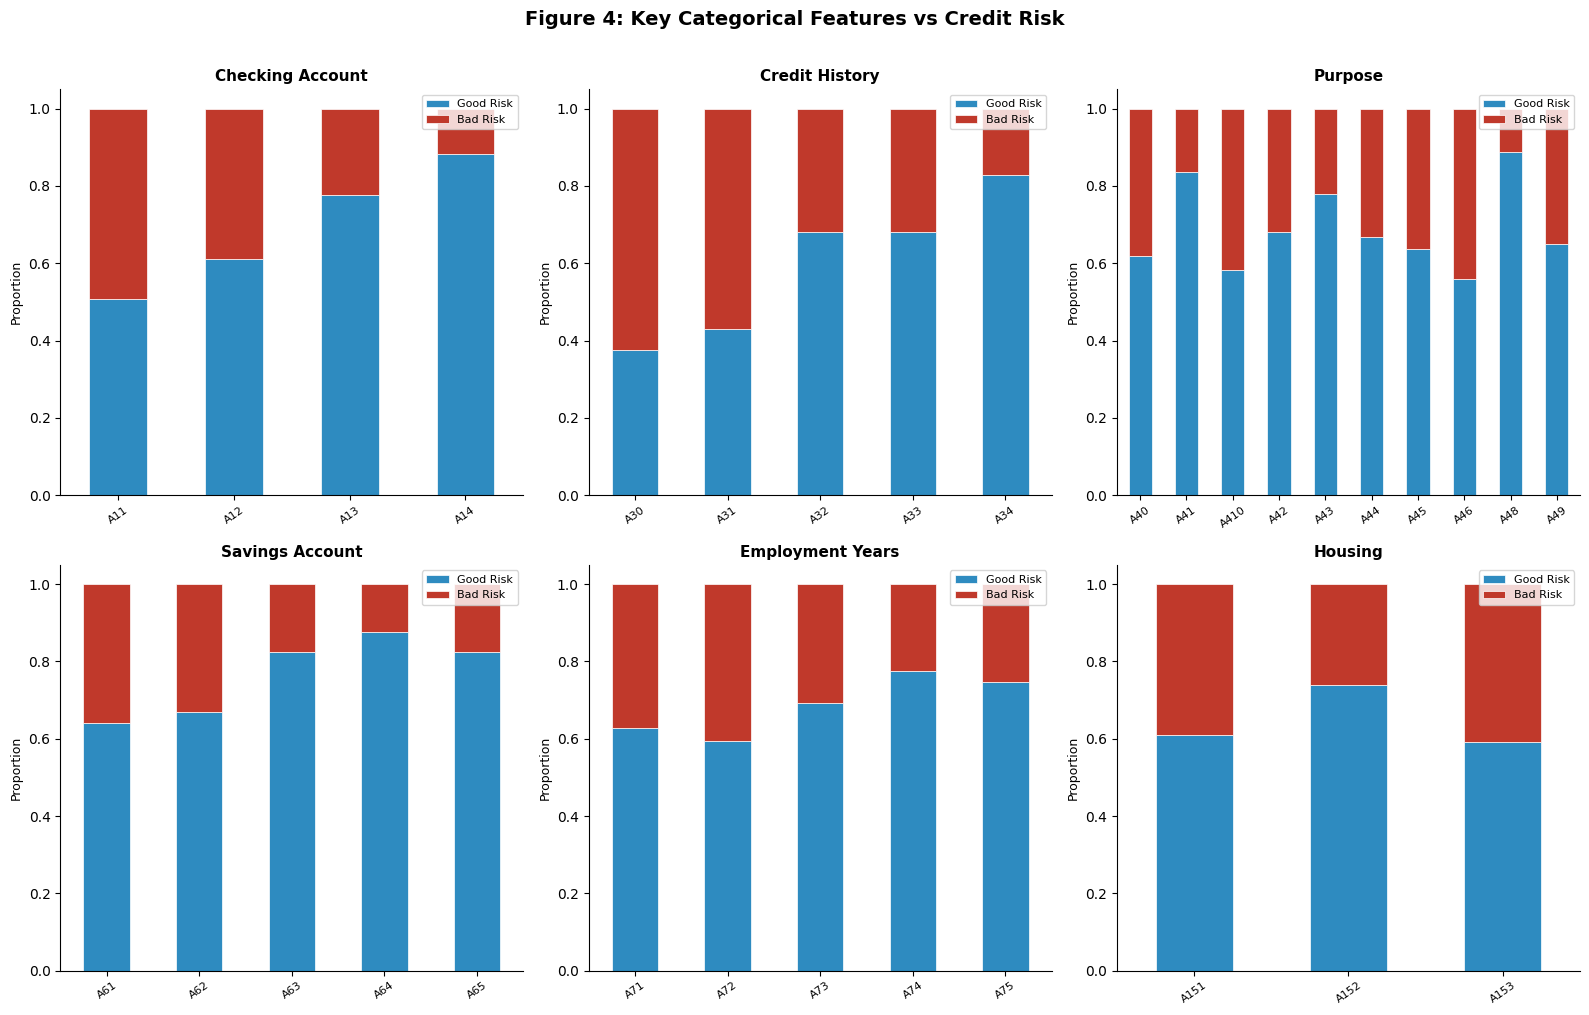

Saved: shap_plots/categorical_vs_risk.png


In [11]:
# Top 6 categorical features vs credit risk
top_cat = ['checking_account', 'credit_history', 'purpose',
           'savings_account', 'employment_years', 'housing']

# If any of these are already encoded as numbers, skip them
cat_to_plot = [c for c in top_cat if c in cat_cols]
if len(cat_to_plot) < 6:
    cat_to_plot = cat_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['credit_risk'], normalize='index')
    ct.columns = ['Good Risk', 'Bad Risk']
    ct.plot(kind='bar', ax=ax,
            color=['#2E8BC0', '#C0392B'],
            stacked=True, edgecolor='white', linewidth=0.5)
    ax.set_title(col.replace('_', ' ').title(),
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Proportion', fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Figure 4: Key Categorical Features vs Credit Risk',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../shap_plots/categorical_vs_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_plots/categorical_vs_risk.png")

In [12]:
# Summary statistics for the dissertation
print("=" * 60)
print("TABLE 1: Dataset Summary — UCI German Credit")
print("=" * 60)
print(f"Total records:         {len(df)}")
print(f"Total features:        {len(df.columns) - 1}")
print(f"Categorical features:  {len(cat_cols)}")
print(f"Numerical features:    {len(num_cols)}")
print(f"Missing values:        {df.isnull().sum().sum()}")
print(f"Good credit (class 0): {(df['credit_risk']==0).sum()} ({(df['credit_risk']==0).mean():.1%})")
print(f"Bad credit (class 1):  {(df['credit_risk']==1).sum()} ({(df['credit_risk']==1).mean():.1%})")
print(f"Class imbalance ratio: {(df['credit_risk']==0).sum()/(df['credit_risk']==1).sum():.1f}:1")
print(f"Cost matrix:           Misclass bad→good costs 5x more")
print(f"\nNumerical feature statistics:")
print(df[num_cols].describe().round(2))

TABLE 1: Dataset Summary — UCI German Credit
Total records:         1000
Total features:        20
Categorical features:  13
Numerical features:    7
Missing values:        0
Good credit (class 0): 700 (70.0%)
Bad credit (class 1):  300 (30.0%)
Class imbalance ratio: 2.3:1
Cost matrix:           Misclass bad→good costs 5x more

Numerical feature statistics:
       duration_months  credit_amount  installment_rate  residence_years  \
count          1000.00        1000.00           1000.00          1000.00   
mean             20.90        3271.26              2.97             2.84   
std              12.06        2822.74              1.12             1.10   
min               4.00         250.00              1.00             1.00   
25%              12.00        1365.50              2.00             2.00   
50%              18.00        2319.50              3.00             3.00   
75%              24.00        3972.25              4.00             4.00   
max              72.00       184